## Parte analítica problema paracaidista

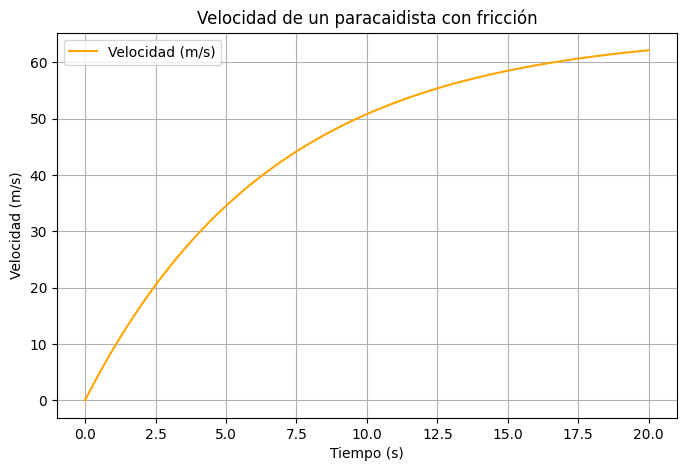

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos
m = 80      # masa (kg)
g = 9.81    # gravedad (m/s²)
k = 12      # coeficiente de fricción (kg/s)

# Tiempo
t = np.linspace(0, 20, 1000)

# Velocidad analítica del paracaidista
v = (m * g / k) * (1 - np.exp(-k * t / m))

# Graficar velocidad
plt.figure(figsize=(8, 5))
plt.plot(t, v, label="Velocidad (m/s)", color='orange')
plt.title("Velocidad de un paracaidista con fricción")
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (m/s)")
plt.grid(True)
plt.legend()
plt.show()


# RNN Simple

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1536
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.2403e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7159e-04
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.9914e-05
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8158e-05
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.5321e-05
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.6185e-06
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1144e-06
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.1510e-06
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.8176e-06
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.5770e-06
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.5328e-06
Epoch 13/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.5693e-06
Epoch 14/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.5161e-06
Epoch 15/50
30/30 ━

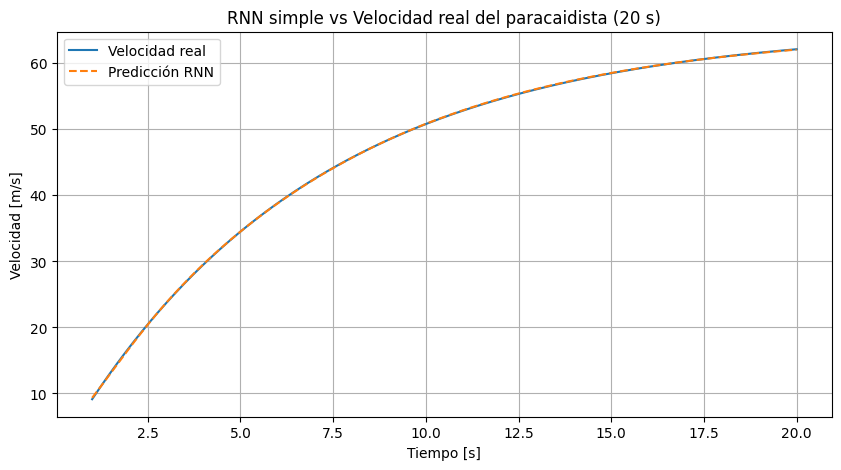

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Parámetros físicos
m = 80      # masa (kg)
g = 9.81    # gravedad (m/s²)
k = 12      # fricción (kg/s)

# Tiempo para 20 segundos
t = np.linspace(0, 20, 1000)

# Velocidad analítica
v_t = (m * g / k) * (1 - np.exp(-k * t / m))

# Escalar datos
x = v_t.reshape(-1, 1)
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

# Crear secuencias
def crear_secuencias(data, paso):
    X, y = [], []
    for i in range(len(data) - paso):
        X.append(data[i:i+paso])
        y.append(data[i+paso])
    return np.array(X), np.array(y)

paso = 50
X, y = crear_secuencias(x_scaled, paso)

# Modelo RNN actualizado
model_rnn = Sequential()
# 1. Definimos la entrada primero
model_rnn.add(Input(shape=(paso, 1))) 
# 2. Luego añadimos la capa recurrente (ya sin input_shape)
model_rnn.add(SimpleRNN(50, activation='tanh')) 
model_rnn.add(Dense(1))

# Entrenamiento
model_rnn.fit(X, y, epochs=50, batch_size=32, verbose=1)

# Predicción
x_pred_rnn = model_rnn.predict(X)
x_pred_rnn_inv = scaler.inverse_transform(x_pred_rnn)
y_real_inv = scaler.inverse_transform(y)

# Gráfica
plt.figure(figsize=(10,5))
plt.plot(t[paso:], y_real_inv, label='Velocidad real')
plt.plot(t[paso:], x_pred_rnn_inv, label='Predicción RNN', linestyle='--')
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.title("RNN simple vs Velocidad real del paracaidista (20 s)")
plt.legend()
plt.grid(True)
plt.show()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5624   
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0097 
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4995e-05 
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6408e-06 
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3757e-06 
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0971e-06 
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.7359e-07 
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.5455e-07 
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.4505e-07 
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.8419e-07 
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0704e-07 
Epoch 13/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.3920e-07 
Epoch 14/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7005e-07 
Epoch 15/50
30/30 ━━━━━━━

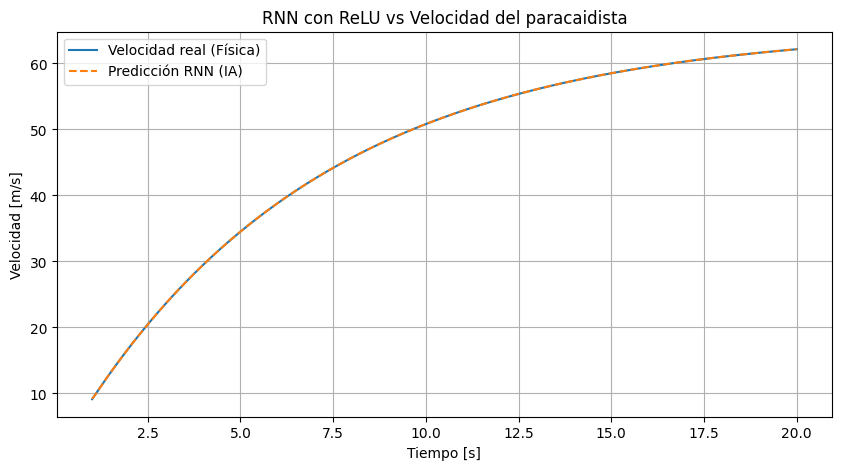

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

# 1. Parámetros físicos
m = 80      # masa (kg)
g = 9.81    # gravedad (m/s²)
k = 12      # fricción (kg/s)

# Tiempo para 20 segundos
t = np.linspace(0, 20, 1000)

# Velocidad analítica (Fórmula física)
v_t = (m * g / k) * (1 - np.exp(-k * t / m))

# 2. Escalar datos
x = v_t.reshape(-1, 1)
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

# 3. Crear secuencias para la RNN
def crear_secuencias(data, paso):
    X, y = [], []
    for i in range(len(data) - paso):
        X.append(data[i:i+paso])
        y.append(data[i+paso])
    return np.array(X), np.array(y)

paso = 50
X, y = crear_secuencias(x_scaled, paso)

# 4. Modelo RNN actualizado (Keras 3 compatible)
model_rnn = Sequential([
    Input(shape=(paso, 1)),
    SimpleRNN(50, activation='relu'), 
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.summary()

# 5. Entrenamiento
model_rnn.fit(X, y, epochs=50, batch_size=32, verbose=1)

# 6. Predicción
x_pred_rnn = model_rnn.predict(X)
x_pred_rnn_inv = scaler.inverse_transform(x_pred_rnn)
y_real_inv = scaler.inverse_transform(y)

# 7. Gráfica
plt.figure(figsize=(10,5))
plt.plot(t[paso:], y_real_inv, label='Velocidad real (Física)')
plt.plot(t[paso:], x_pred_rnn_inv, label='Predicción RNN (IA)', linestyle='--')
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.title("RNN con ReLU vs Velocidad del paracaidista")
plt.legend()
plt.grid(True)
plt.show()

2. Calcular métricas de error

Entrenando modelos... esto tomará unos segundos.
----------------------------------------
MSE con Activación ReLU: 0.000003
MSE con Activación Tanh: 0.002978
----------------------------------------


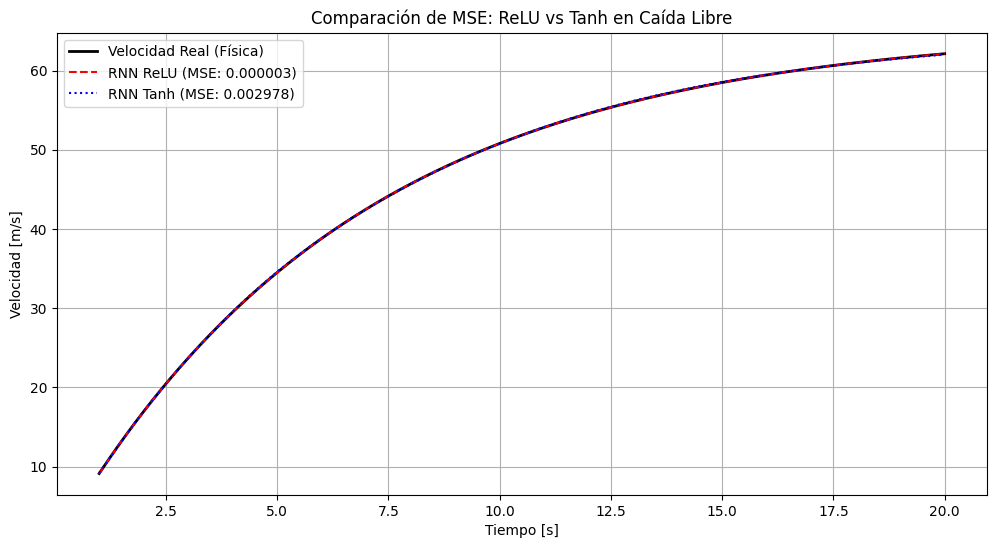

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

# --- 1. PREPARACIÓN DE DATOS ---
m, g, k = 80, 9.81, 12
t = np.linspace(0, 20, 1000)
v_t = (m * g / k) * (1 - np.exp(-k * t / m))

x = v_t.reshape(-1, 1)
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

def crear_secuencias(data, paso):
    X, y = [], []
    for i in range(len(data) - paso):
        X.append(data[i:i+paso])
        y.append(data[i+paso])
    return np.array(X), np.array(y)

paso = 50
X, y = crear_secuencias(x_scaled, paso)
y_real_inv = scaler.inverse_transform(y) # Valores reales en m/s

# --- 2. FUNCIÓN PARA ENTRENAR Y EVALUAR ---
def evaluar_activacion(tipo_activacion):
    model = Sequential([
        Input(shape=(paso, 1)),
        SimpleRNN(50, activation=tipo_activacion),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    
    # Entrenamos (verbose=0 para no llenar el log de Colab)
    model.fit(X, y, epochs=50, batch_size=32, verbose=0)
    
    # Predicción e inversión de escala
    preds = model.predict(X, verbose=0)
    preds_inv = scaler.inverse_transform(preds)
    
    # Cálculo del MSE
    mse = mean_squared_error(y_real_inv, preds_inv)
    return preds_inv, mse

# --- 3. EJECUCIÓN DE LA COMPARATIVA ---
print("Entrenando modelos... esto tomará unos segundos.")
preds_relu, mse_relu = evaluar_activacion('relu')
preds_tanh, mse_tanh = evaluar_activacion('tanh')

# --- 4. RESULTADOS Y GRÁFICA ---
print("-" * 40)
print(f"MSE con Activación ReLU: {mse_relu:.6f}")
print(f"MSE con Activación Tanh: {mse_tanh:.6f}")
print("-" * 40)

plt.figure(figsize=(12, 6))
plt.plot(t[paso:], y_real_inv, 'k', label='Velocidad Real (Física)', linewidth=2)
plt.plot(t[paso:], preds_relu, 'r--', label=f'RNN ReLU (MSE: {mse_relu:.6f})')
plt.plot(t[paso:], preds_tanh, 'b:', label=f'RNN Tanh (MSE: {mse_tanh:.6f})')

plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.title("Comparación de MSE: ReLU vs Tanh en Caída Libre")
plt.legend()
plt.grid(True)
plt.show()

4. Simule otros escenarios con diferentes masas y coeficientes de fricción.

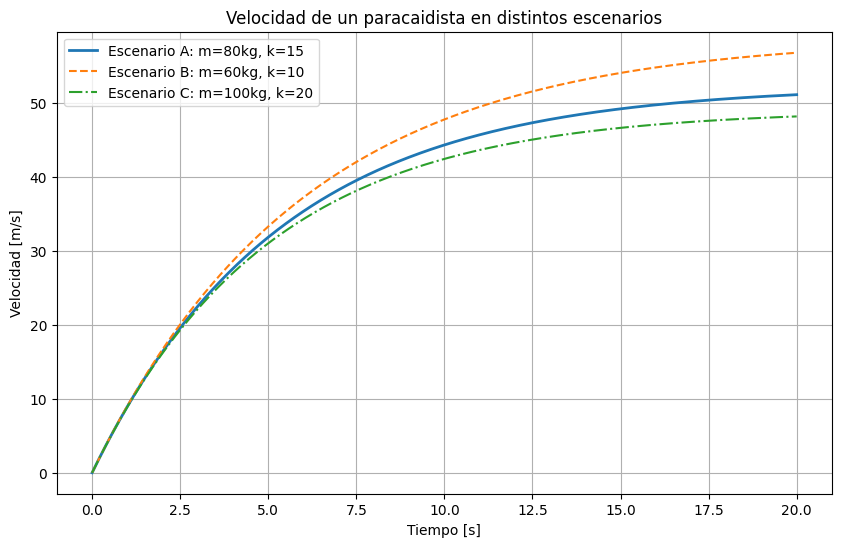

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81  # gravedad (m/s²)
t = np.linspace(0, 20, 1000)

# Función velocidad analítica
def velocidad(m, k, t):
    return (m * g / k) * (1 - np.exp(-k * t / m))

# Escenarios
v_A = velocidad(80, 15, t)   # Escenario A
v_B = velocidad(60, 10, t)   # Escenario B
v_C = velocidad(100, 20, t)  # Escenario C

# Graficar
plt.figure(figsize=(10,6))
plt.plot(t, v_A, label="Escenario A: m=80kg, k=15", linewidth=2)
plt.plot(t, v_B, label="Escenario B: m=60kg, k=10", linestyle='--')
plt.plot(t, v_C, label="Escenario C: m=100kg, k=20", linestyle='-.')
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.title("Velocidad de un paracaidista en distintos escenarios")
plt.grid(True)
plt.legend()
plt.show()


Entrenando red multiescenario...


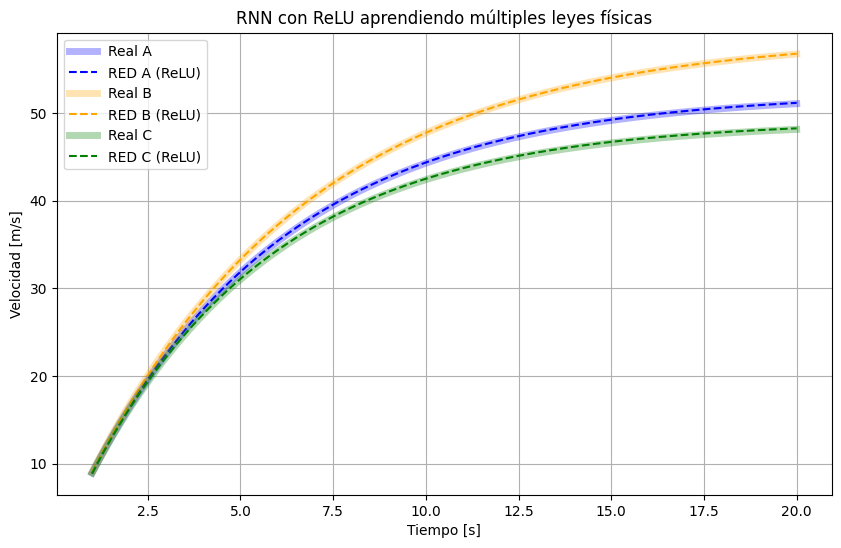

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

# 1. Parámetros y Generación de Datos
g = 9.81
t = np.linspace(0, 20, 1000)

def velocidad(m, k, t):
    return (m * g / k) * (1 - np.exp(-k * t / m))

# Generamos los 3 escenarios
escenarios = [
    (80, 15, "A"),
    (60, 10, "B"),
    (100, 20, "C")
]

# Preparar datos para entrenamiento (Concatenamos los escenarios)
all_data = []
for m, k, nombre in escenarios:
    v = velocidad(m, k, t)
    all_data.append(v.reshape(-1, 1))

# Unimos todo en un solo array para el escalador
data_combined = np.vstack(all_data)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_combined)

# 2. Crear secuencias (X contendrá la ventana de tiempo)
def crear_secuencias(data, paso):
    X, y = [], []
    for i in range(len(data) - paso):
        X.append(data[i:i+paso])
        y.append(data[i+paso])
    return np.array(X), np.array(y)

paso = 50
# Dividimos los datos escalados de nuevo para crear secuencias por separado
# (Evitamos que el final de un escenario se mezcle con el inicio de otro)
X_list, y_list = [], []
for i in range(len(escenarios)):
    start = i * 1000
    end = (i + 1) * 1000
    Xi, yi = crear_secuencias(data_scaled[start:end], paso)
    X_list.append(Xi)
    y_list.append(yi)

X = np.vstack(X_list)
y = np.vstack(y_list)

# 3. Modelo RNN con ReLU
model = Sequential([
    Input(shape=(paso, 1)),
    SimpleRNN(50, activation='relu', return_sequences=False),
    Dense(32, activation='relu'), # Capa densa extra para ayudar a la generalización
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
print("Entrenando red multiescenario...")
model.fit(X, y, epochs=30, batch_size=32, verbose=0)

# 4. Predicción y Gráfica
plt.figure(figsize=(10,6))
colores = ['blue', 'orange', 'green']

for i, (m, k, nombre) in enumerate(escenarios):
    # Predecir para cada escenario
    y_pred = model.predict(X_list[i], verbose=0)
    y_pred_inv = scaler.inverse_transform(y_pred)
    y_real_inv = scaler.inverse_transform(y_list[i])
    
    # Graficar
    plt.plot(t[paso:], y_real_inv, color=colores[i], alpha=0.3, linewidth=5, label=f"Real {nombre}")
    plt.plot(t[paso:], y_pred_inv, color=colores[i], linestyle='--', label=f"RED {nombre} (ReLU)")

plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.title("RNN con ReLU aprendiendo múltiples leyes físicas")
plt.legend()
plt.grid(True)
plt.show()

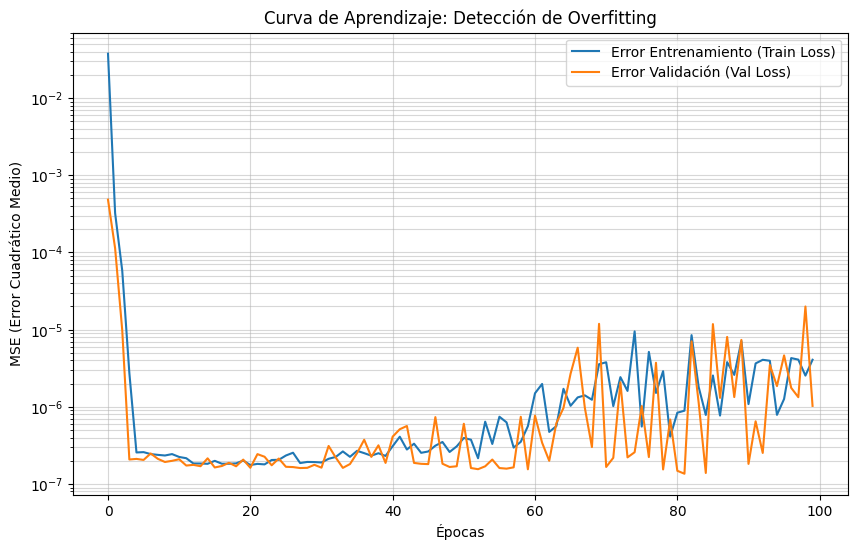

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

# 1. Usamos los datos X e y generados en el paso anterior
# Separamos 20% para validación (datos que la red no usará para ajustar pesos)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Reconstruimos el modelo con ReLU
model_ov = Sequential([
    Input(shape=(paso, 1)),
    SimpleRNN(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model_ov.compile(optimizer='adam', loss='mse')

# 3. Entrenamiento guardando el historial
# validation_data nos permite ver el error en datos "nuevos" en cada época
history = model_ov.fit(
    X_train, y_train, 
    epochs=100,           # Aumentamos épocas para forzar el posible overfitting
    batch_size=32, 
    validation_data=(X_val, y_val), 
    verbose=0
)

# 4. Gráfica de la Curva de Aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Error Entrenamiento (Train Loss)')
plt.plot(history.history['val_loss'], label='Error Validación (Val Loss)')

plt.title("Curva de Aprendizaje: Detección de Overfitting")
plt.xlabel("Épocas")
plt.ylabel("MSE (Error Cuadrático Medio)")
plt.yscale('log') # Usamos escala logarítmica para ver mejor los errores pequeños
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()